# SAMI · Notebook 2 — Demand, behaviour & experience

**Mandate (Acts 2–3, quantitative).** What are people asking the bot, how does that
demand move across cities and weeks, how far does engagement carry, and how satisfied
are the few who tell us? Every figure carries an assertion-evidence title, its metric,
its n, and the observation window; every number traces to the P10 reconciliation table
reproduced at the top and bottom of this notebook. Modules compute, this notebook
consumes — no analytical logic lives in a cell.

> **Grain note.** Messages inherit the timestamp of their response record (there is no
> per-message timestamp). All weekly and daily trends are therefore at
> **record-arrival granularity**, not true per-message time.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sami import load_sami, stats, metrics, taxonomy, theme, canon

CAT_ORDER = taxonomy.OFFICIAL_CATEGORIES + ["unclassified"]
CAT_COLOR = dict(zip(CAT_ORDER, theme.bar_colors(len(CAT_ORDER))))
CAT_EN = {  # EN display for category labels (chart text only)
    "legal_documentation": "Legal & documentation",
    "humanitarian_assistance": "Humanitarian assistance",
    "protection": "Protection",
    "employment": "Employment",
    "organization_search": "Finding organizations",
    "journey_information": "Journey information",
    "services": "Services",
    "unclassified": "Unclassified",
}
SD = load_sami()
WINDOW = f"{SD.run_meta['ts_min'][:10]} → {SD.run_meta['ts_max'][:10]}"


In [2]:
print("Source:", SD.run_meta["responses_file"], "|", SD.run_meta["responses_rows"], "rows |", WINDOW)
recon_top = SD.reconciliation.copy()
recon_top


Source: MMC_bot_responses_1783087815.xlsx | 948 rows | 2026-03-25 → 2026-07-03


,metric,value
0,users,917
1,records,946
2,messages,2991
3,users_with_text,800
4,meal_responses,69
5,meal_response_rate_pct,7.5
6,legal_documentation_pct,51.7
7,repeat_askers_pct,11.9
8,negative_tone_pct,pending


## 1 · Demand mix

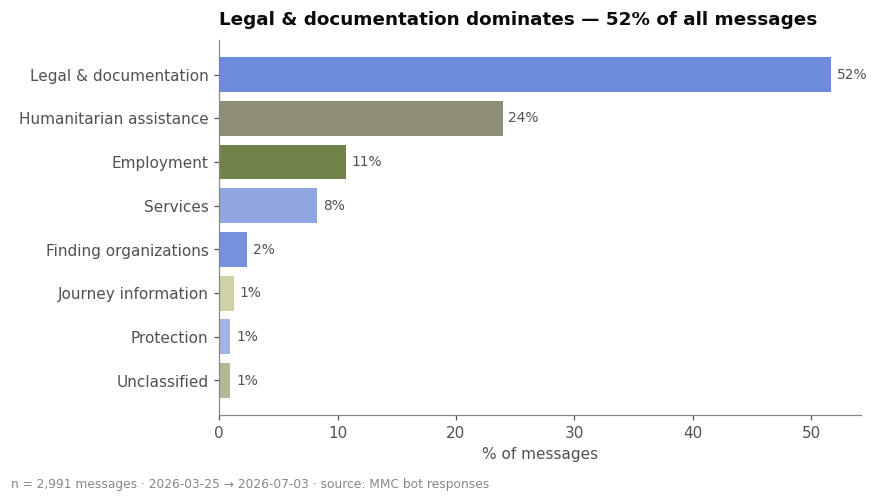

In [3]:
share = metrics.category_share(SD.messages).rename(index=CAT_EN)
fig, ax = plt.subplots(figsize=(8, 4.4))
colors = [CAT_COLOR[k] for k in metrics.category_share(SD.messages).index]
ax.barh(share.index[::-1], (share.values * 100)[::-1], color=colors[::-1])
for y, v in enumerate((share.values * 100)[::-1]):
    ax.text(v + 0.5, y, f"{v:.0f}%", va="center", fontsize=9, color=theme.INK2)
ax.set_xlabel("% of messages")
ax.set_title(f"Legal & documentation dominates — {share.iloc[0]*100:.0f}% of all messages")
ax.set_ylabel("")
n = len(SD.messages)
fig.text(0.01, -0.02, f"n = {n:,} messages · {WINDOW} · source: MMC bot responses", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


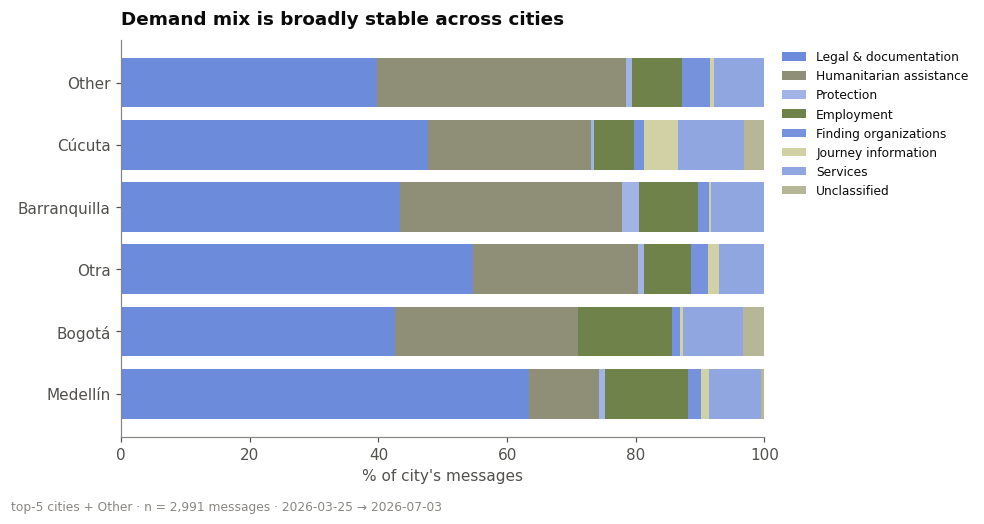

In [4]:
mix = metrics.city_category_mix(SD.messages, top_cities=5)
mix_en = mix.rename(columns=CAT_EN)
fig, ax = plt.subplots(figsize=(9, 4.6))
left = np.zeros(len(mix_en))
for cat in [c for c in CAT_ORDER if CAT_EN[c] in mix_en.columns]:
    vals = mix_en[CAT_EN[cat]].values * 100
    ax.barh(mix_en.index, vals, left=left, color=CAT_COLOR[cat], label=CAT_EN[cat])
    left += vals
ax.set_xlabel("% of city's messages"); ax.set_ylabel("")
ax.set_title("Demand mix is broadly stable across cities")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
fig.text(0.01, -0.02, f"top-5 cities + Other · n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


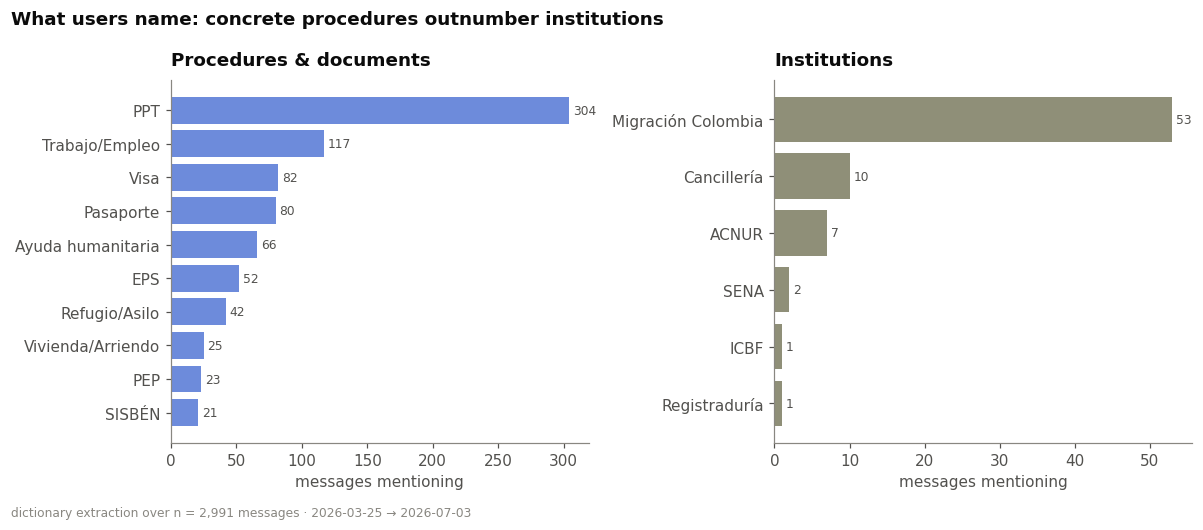

In [5]:
by_kind = taxonomy.entity_counts_by_kind(SD.messages["message"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, kind, title in [(axes[0], "procedure", "Procedures & documents"),
                        (axes[1], "institution", "Institutions")]:
    s = by_kind[kind].head(10)
    ax.barh(s.index[::-1], s.values[::-1], color=theme.PRIMARY if kind=="procedure" else theme.MADERA)
    for y, v in enumerate(s.values[::-1]):
        ax.text(v + max(s.values)*0.01, y, str(int(v)), va="center", fontsize=8, color=theme.INK2)
    ax.set_title(title); ax.set_xlabel("messages mentioning")
axes[0].figure.suptitle("What users name: concrete procedures outnumber institutions", x=0.01, ha="left", fontsize=12, weight="semibold")
fig.text(0.01, -0.02, f"dictionary extraction over n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()
